# judge-audit — demo

**Your eval is a measurement instrument. Audit it like one.**

This notebook builds a synthetic LLM judge with *known* pathologies, then shows `judge-audit` recovering them across three axes (reliability, systematic bias, drift) plus a calibration correction with honest error bars. Same *inject → recover* idea as model-collapse-testbed.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import judge_audit as ja
print('judge-audit', ja.__version__)

judge-audit 0.1.0


## 1. Build a judge with injected pathologies

`JudgeSpec` controls the planted biases; `make_benchmark` simulates 12 batches of judgements plus a fixed anchor set and a pairwise (order-swapped) subset.

In [2]:
spec = ja.JudgeSpec()
bench = ja.make_benchmark(spec)
spec.truth  # the ground-truth magnitudes we'll try to recover

{'verbosity_coef': 0.45,
 'sigma_judge': 0.4,
 'drift_changepoint': 7,
 'first_pos_pref': 0.68,
 'gamma': 1.6}

## 2. Run the full audit

`audit()` runs every axis whose data is present and returns a nested dict. On a real log some axes may be absent — that's fine.

In [3]:
a = ja.audit(bench)
list(a.keys())

['scale', 'n_items', 'reliability', 'bias', 'drift', 'calibration', 'truth']

### Axis 1 — reliability & validity
Self-consistency is the *ceiling*: if the judge disagrees with itself, nothing downstream can be trusted.

In [4]:
r = a['reliability']
print('self-consistency  alpha :', round(r['self_consistency']['alpha'], 3))
print('self-consistency  flip  :', round(r['self_consistency']['flip_rate'], 3))
print('validity Spearman rho   :', round(r['spearman_vs_human'], 3))
print('validity interval alpha :', round(r['alpha_vs_human'], 3))

self-consistency  alpha : 0.847
self-consistency  flip  : 0.683
validity Spearman rho   : 0.795
validity interval alpha : 0.65


### Axis 2 — systematic bias (controlled perturbation)
Position bias from order-swapped pairwise verdicts; verbosity bias from an OLS that partials out true quality.

In [5]:
b = a['bias']
print('first-slot rate  :', round(b['position']['first_pos_rate'], 3),
      '(injected', spec.truth['first_pos_pref'], ')')
print('order flip rate  :', round(b['position']['flip_rate'], 3))
print('verbosity coef/SD:', round(b['verbosity']['length_coef_per_sd'], 3),
      '(injected', spec.truth['verbosity_coef'], ', t =',
      round(b['verbosity']['t_stat'], 1), ')')

first-slot rate  : 0.705 (injected 0.68 )
order flip rate  : 0.583
verbosity coef/SD: 0.366 (injected 0.45 , t = 22.6 )


### Axis 3 — drift on the anchor set
The provider silently ships a new model version at batch 7. An EWMA control chart on the fixed anchor set catches the shift.

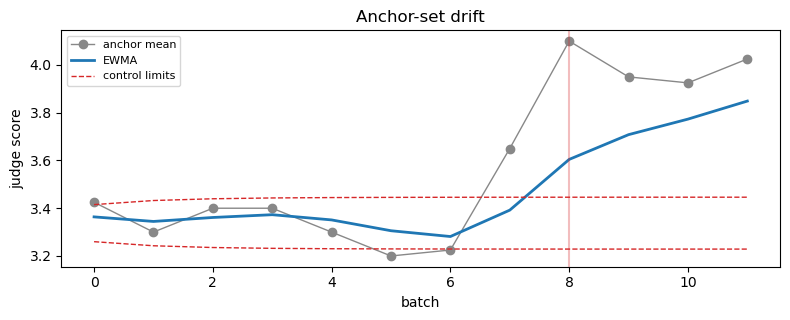

EWMA first alarm at batch 8 | injected changepoint 7


In [6]:
d = a['drift']
ew = d['ewma']
x = np.arange(len(d['anchor_means']))
plt.figure(figsize=(8, 3.3))
plt.plot(x, d['anchor_means'], 'o-', color='#888', lw=1, label='anchor mean')
plt.plot(x, ew['ewma'], color='#1f77b4', lw=2, label='EWMA')
plt.plot(x, ew['ucl'], '--', color='#d62728', lw=1, label='control limits')
plt.plot(x, ew['lcl'], '--', color='#d62728', lw=1)
if ew['first_alarm'] is not None:
    plt.axvline(ew['first_alarm'], color='#d62728', alpha=0.3)
plt.title('Anchor-set drift'); plt.xlabel('batch'); plt.ylabel('judge score')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()
print('EWMA first alarm at batch', ew['first_alarm'],
      '| injected changepoint', spec.truth['drift_changepoint'])

## 3. Calibration — map judge scores onto the human scale
Isotonic regression fit on a calibration split, evaluated on held-out data. ECE drops sharply; the raw curve bows below the diagonal (the judge compresses the top of the scale).

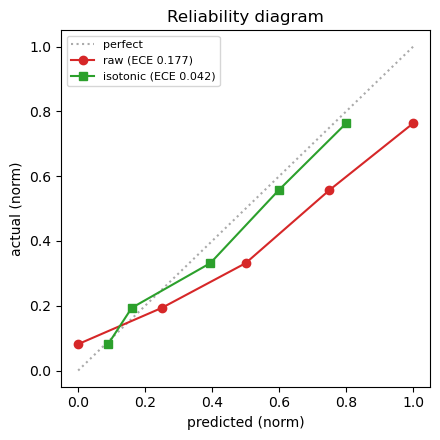

In [7]:
c = a['calibration']
xb, yb = c['curve_before']; xa, ya = c['curve_after']
plt.figure(figsize=(4.5, 4.5))
plt.plot([0,1],[0,1], ':', color='#aaa', label='perfect')
plt.plot(xb, yb, 'o-', color='#d62728', label=f"raw (ECE {c['before']['ece']:.3f})")
plt.plot(xa, ya, 's-', color='#2ca02c', label=f"isotonic (ECE {c['after']['ece']:.3f})")
plt.xlabel('predicted (norm)'); plt.ylabel('actual (norm)')
plt.title('Reliability diagram'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Don't read noise as signal
Two models with a 0.05-pt true quality gap. The bootstrap CI on the judged difference straddles 0 — so the leaderboard **cannot** call a winner.

In [8]:
tm = ja.two_model_scores(spec, true_gap=0.05)
diff = ja.bootstrap_diff(tm['a'], tm['b'], seed=1)
print(f"A - B = {diff['diff']:+.3f}  95% CI [{diff['lo']:+.3f}, {diff['hi']:+.3f}]")
print('significant:', diff['significant'])

A - B = +0.030  95% CI [-0.160, +0.207]
significant: False


## 5. Inject → recover scorecard

In [9]:
print(ja.render_markdown(a))

# Judge audit report

Treats the LLM judge as a measurement instrument and reports its reliability, systematic bias, temporal drift, and calibration.

_Audited 1440 judgements; axes shown are those the data supports._

## TL;DR

- **Self-consistency** (ceiling on everything): Krippendorff α = `0.847`, flip-rate `68.3%`, mean item σ `0.32` pts.
- **Validity vs human**: Spearman ρ = `0.795`, interval α = `0.650`.
- **Position bias**: first-slot rate `70.5%` (0.5 = neutral); order flips the verdict `58.3%` of the time.
- **Verbosity bias**: `+0.366` pts per +1 SD length (t = 22.6), quality partialled out.
- **Drift**: anchor-set EWMA alarms at **batch 8** (injected changepoint = 7).
- **Calibration**: ECE `0.177` → `0.042` after isotonic correction (−76%).

## Inject → recover check

| pathology | injected | recovered |
|---|---|---|
| verbosity coef (pts/SD) | 0.45 | 0.366 |
| self-consistency σ (pts) | 0.4 | 0.318 |
| first-slot preference | 0.68 | 0.705 |
| drift changepoint (batch) | 

## 6. Same audit on a real eval log
The `io` adapter turns a CSV/JSONL log into the same dict. Run
`python make_sample_log.py` first to create `data/eval_log.jsonl`.

In [10]:
log_path = 'data/eval_log.jsonl'
if os.path.exists(log_path):
    import json
    recs = ja.read_jsonl(log_path)
    anchors = json.load(open('data/anchor_ids.json'))
    blog = ja.assemble(recs, scale=(1,5), anchor_ids=anchors)
    blog.update(ja.pairwise(ja.read_jsonl('data/pairwise_log.jsonl')))
    alog = ja.audit(blog)
    print('axes from real log:',
          [k for k in ('reliability','bias','drift','calibration') if k in alog])
else:
    print('run: python make_sample_log.py')

axes from real log: ['reliability', 'bias', 'drift', 'calibration']
